In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.stats import linregress

In [ ]:
def linear_fit_plot(x, y,p):
    # TO RUN: import numpy as np, matplotlib.pyplot as plt and from scipy.stats import linregress
    result = linregress(x, y)
    m = result.slope
    c = result.intercept
    m_err = result.stderr
    c_err = result.intercept_stderr

    x_fit = np.linspace(min(x), max(x), 100)
    y_fit = m * x_fit + c
    if p == True:
        plt.plot(x_fit, y_fit, linestyle='--',label=f'Fitted: y = ({m:.3f} ± {m_err:.3f})x + ({c*1e3:.3f} ± {c_err*1e3:.3f})x 10^-3', color='red', linewidth=2)
    if p == False:
         plt.plot(x_fit, y_fit, linestyle='--',label=f'Fitted: y = ({m:.3f} ± {m_err:.3f})x + ({c:.3f} ± {c_err:.3f})', color='red', linewidth=2)
        
    plt.legend()

In [7]:
# DATA
# 3-bit DAC
bin_D3 = {0:'000',1:'001',2:'010',3:'011',4:'100',5:'101',6:'110',7:'111'}
Aop_D3 =[-0.001 ,-1.277,-2.567,-3.846 ,-5.120 ,-6.400 ,-7.690 ,-8.970 ] # in V
theo_D3 = [0,-1.25 ,- 2.5 ,- 3.75,- 5.00,- 6.25,- 7.5 ,- 8.75]

# 4-bit 
bin_D4 = {0:'0000',1:'0001',2:'0010',3:'0011',4:'0100',5:'0101',6:'0110',7:'0111',8:'1000',9:'1001',10:'1010',11:'1011',12:'1100',13:'1101',14:'1110',15:'1111'}
Aop_D4 = [-0.001 , -0.641, -1.276,-1.920 ,-2.564 ,-2.624 ,-3.842 ,-4.040 ,-5.120 , -5.760, -6.390,-7.040 ,-7.680 ,-8.320 ,-8.960 ,-9.600 ] # in V
theo_D4 = [0,-0.625,-1.25,-1.875,-2.5,-3.75,-4.375,-5,-5.625,-6.25,-6.875,-7.5,-8.125,-8.75,-9.375,-10]
# 2-bit ADC
Ain_A2 =[0,1.3,2.6,3.8] #in V
bop_A2 ={0:'00',1:'01',2:'10',3:'11'}

0.13
0.509


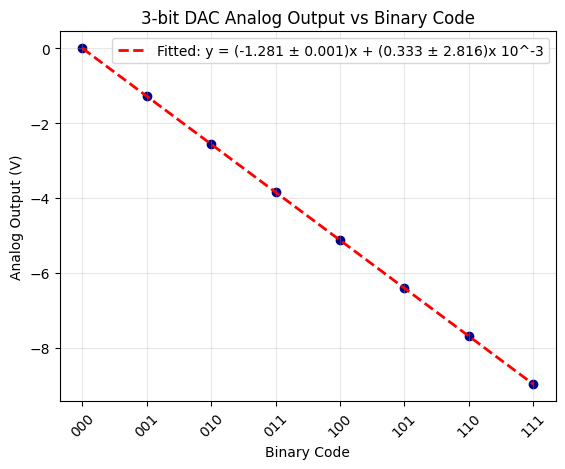

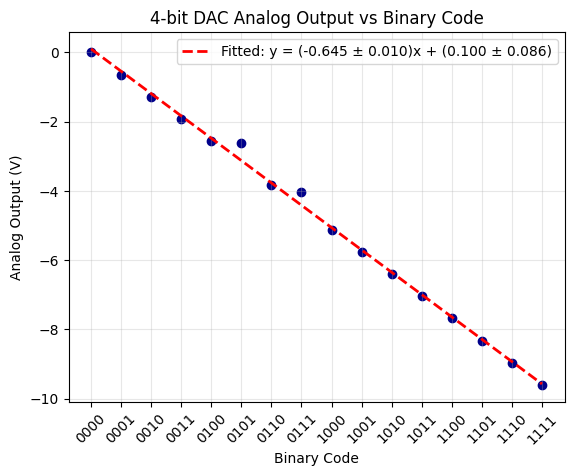

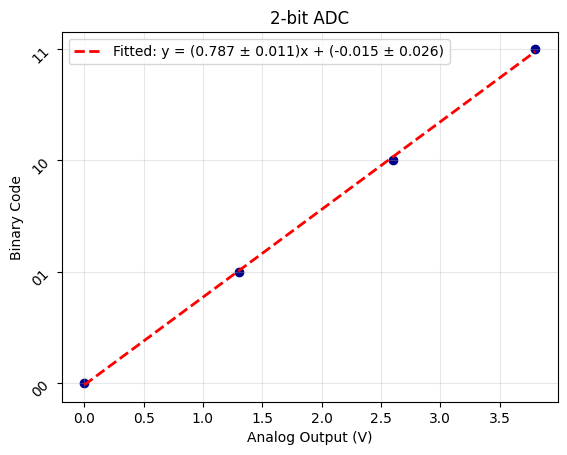

In [8]:
def rms_cal(Vobs,Vtheo):
    r=0
    for i in range(len(Vobs)):
        r += (Vobs[i]-Vtheo[i])**2
    r = np.sqrt(r/len(Vobs))
    return round(r,3)

print(rms_cal(Aop_D3,theo_D3))
print(rms_cal(Aop_D4,theo_D4))

def dcafit(bin_D3,Aop_D3,bit,p):
    x_num = list(bin_D3.keys())
    x_str = list(bin_D3.values())
    linear_fit_plot(x_num, Aop_D3,p)
    plt.scatter(x_num, Aop_D3,color='darkblue')
    plt.xticks(x_num, x_str, rotation=45)
    plt.xlabel('Binary Code')
    plt.ylabel('Analog Output (V)')
    plt.title(f'{bit}-bit DAC Analog Output vs Binary Code')
    plt.grid(True, alpha=0.3)
    plt.show()

dcafit(bin_D3,Aop_D3,3,True)
dcafit(bin_D4,Aop_D4,4,False)
# ADC
y_num = list(bop_A2.keys())
y_str = list(bop_A2.values())
linear_fit_plot(Ain_A2,y_num,False)
plt.scatter(Ain_A2,y_num,color='darkblue')
plt.yticks(y_num, y_str, rotation=45)
plt.ylabel('Binary Code')
plt.xlabel('Analog Output (V)')
plt.title('2-bit ADC')
plt.grid(True, alpha=0.3)
plt.show()

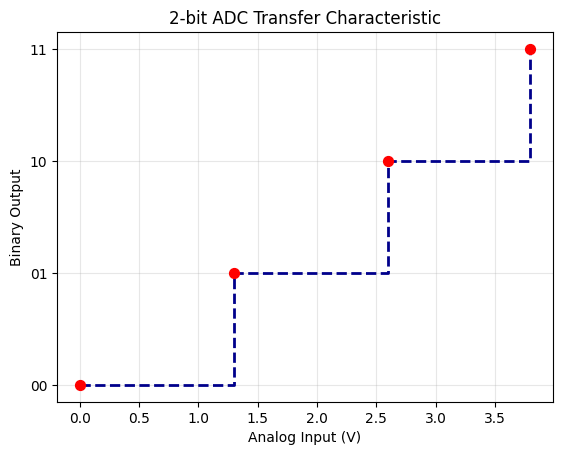

In [5]:
# ADC Ladder Plot
y_num = list(bop_A2.keys())
y_str = list(bop_A2.values())
plt.step(Ain_A2, y_num, linestyle='--',where='post', color='darkblue', linewidth=2)
plt.scatter(Ain_A2, y_num, color='red', s=50, zorder=5)
plt.yticks(y_num, y_str)
plt.xlabel('Analog Input (V)')
plt.ylabel('Binary Output')
plt.title('2-bit ADC Transfer Characteristic')
plt.grid(True, alpha=0.3)
plt.show()